## Code for plotting temperature and salinity along the transects, as well as T-S diagram

In [1]:
import xarray as xr
import numpy as np
import os
import cmocean

import matplotlib as mpl
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap

/home/gabriela/.local/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/gabriela/.local/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
import matplotlib.colors as colors

def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=100):
    new_cmap = colors.LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap

In [4]:
os.chdir('/mnt/storage0/gabriela/ANALYSES/SCRIPTS/data_from_scripts/Temperature')

# Divide by 803 outputs by (number of outputs per year(73) x number of years (2007-2017 = 11 years))

vs = np.load('ANHA4-EJM010-S_Average_Temperature_20071_201712.npz')
vs = vs['Sum_temperature']
temp_vs = vs/803


vd = np.load('ANHA4-EJM012-S_Average_Temperature_20071_201712.npz')
vd = vd['Sum_temperature']
temp_vd = vd/803

os.chdir('/mnt/storage0/gabriela/ANALYSES/SCRIPTS/data_from_scripts/Salinity')

vs = np.load('ANHA4-EJM010-S_Average_Salinity_20071_201712.npz')
vs = vs['Sum_Salinity']
sal_vs = vs/803


vd = np.load('ANHA4-EJM012-S_Average_Salinity_20071_201712.npz')
vd = vd['Sum_Salinity']
sal_vd = vd/803

In [5]:
sal_dif_vdvs = sal_vd - sal_vs
temp_dif_vdvs = temp_vd - temp_vs

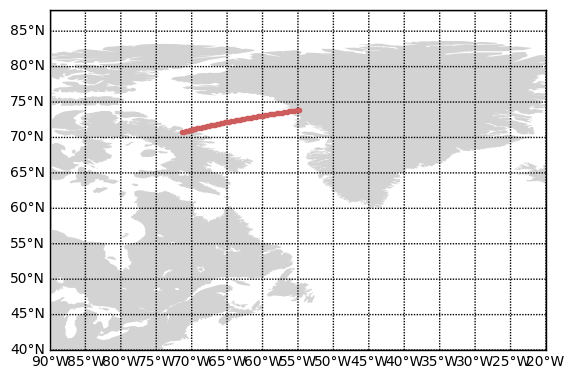

In [17]:
os.chdir('/mnt/storage0/jmarson/ANALYSES/MASKS')

data_mask = xr.open_dataset('ANHA4_mask.nc')

mask = data_mask.variables['tmask']
mask = mask[0][0]

os.chdir('/mnt/storage0/jmarson/NEMO/ANHA4/ANHA4-EJM009-S')

data_grid = xr.open_dataset('ANHA4-EJM009_y2017m12d31_gridT.nc')

lat = data_grid.variables['nav_lat_grid_T']
lon = data_grid.variables['nav_lon_grid_T']
lon = np.asarray(lon)
lat = np.asarray(lat)
depth = data_grid.variables['deptht']
e3t = data_grid.variables['e3t'].mean(dim='time_counter')

#Baffin Bay
slat_bb = 485
slon_bb = np.arange(170, 225) 

#Davis Strait
slat_ds = 440
slon_ds = np.arange(173, 212)

s1 = slat_bb # or slat_ds
s2 = slon_bb # or slon_ds

sec = np.copy(mask)
sec[s1, s2] = 5
sec[np.where(sec != 5)] = np.nan

#Plot to check the transect
m = Basemap(projection='cyl', llcrnrlon=-90, llcrnrlat=40, urcrnrlon=-20, urcrnrlat=88, resolution = 'l')

m.drawmeridians(np.arange(0,360,5), labels=[0, 0, 0, 1])
m.drawparallels(np.arange(-90,90,5), labels=[1, 0, 0, 0])
m.drawmapboundary()
m.fillcontinents(color='lightgray')

lons = lon[s1,s2]
lats = lat[s1,s2]

x, y = m(lons,lats)

m.plot(x, y, marker=".",color='indianred')

plt.show()

In [18]:
sec_lat = lat[ s1, s2]
sec_lon = lon[ s1, s2]
sec_depth = depth[0: len(depth)-15]

mask = xr.open_dataset('/mnt/storage0/jmarson/ANALYSES/MASKS/ANHA4_mask.nc')
tmask = mask.variables['tmask']
tmask = tmask[0, 0:len(sec_depth),s1, s2]

mask = np.zeros(np.shape(tmask))

for i in range(0, len(tmask)):
    for j in range(0, len(tmask[0])):
        if tmask[i][j] == np.float32(1):
            mask[i][j] = np.nan

In [19]:
xp, yp = np.meshgrid(sec_lon, sec_depth)

In [20]:
#Slicing data into the section

sec_sal_vs = sal_vs[0:len(sec_depth), s1, s2]
sec_sal_vd = sal_vd[0:len(sec_depth), s1, s2]

sec_temp_vs = temp_vs[0:len(sec_depth), s1, s2]
sec_temp_vd = temp_vd[0:len(sec_depth), s1, s2]

sal_sec_dif_vdvs = sal_dif_vdvs[0:len(sec_depth), s1, s2]
temp_sec_dif_vdvs = temp_dif_vdvs[0:len(sec_depth), s1, s2]

In [21]:
# Zeros to NaNs

sec_sal_vs = np.where(sal_vs[0:len(sec_depth), s1, s2] == 0, np.nan, sal_vs[0:len(sec_depth), s1, s2])
sec_sal_vd = np.where(sal_vd[0:len(sec_depth), s1, s2] == 0, np.nan, sal_vd[0:len(sec_depth), s1, s2])

sec_temp_vs = np.where(temp_vs[0:len(sec_depth), s1, s2] == 0, np.nan, temp_vs[0:len(sec_depth), s1, s2])
sec_temp_vd = np.where(temp_vd[0:len(sec_depth), s1, s2] == 0, np.nan, temp_vd[0:len(sec_depth), s1, s2])

sal_sec_dif_vdvs = np.where(sal_dif_vdvs[0:len(sec_depth), s1, s2] == 0, np.nan, sal_dif_vdvs[0:len(sec_depth), s1, s2])
temp_sec_dif_vdvs = np.where(temp_dif_vdvs[0:len(sec_depth), s1, s2] == 0, np.nan, temp_dif_vdvs[0:len(sec_depth), s1, s2])


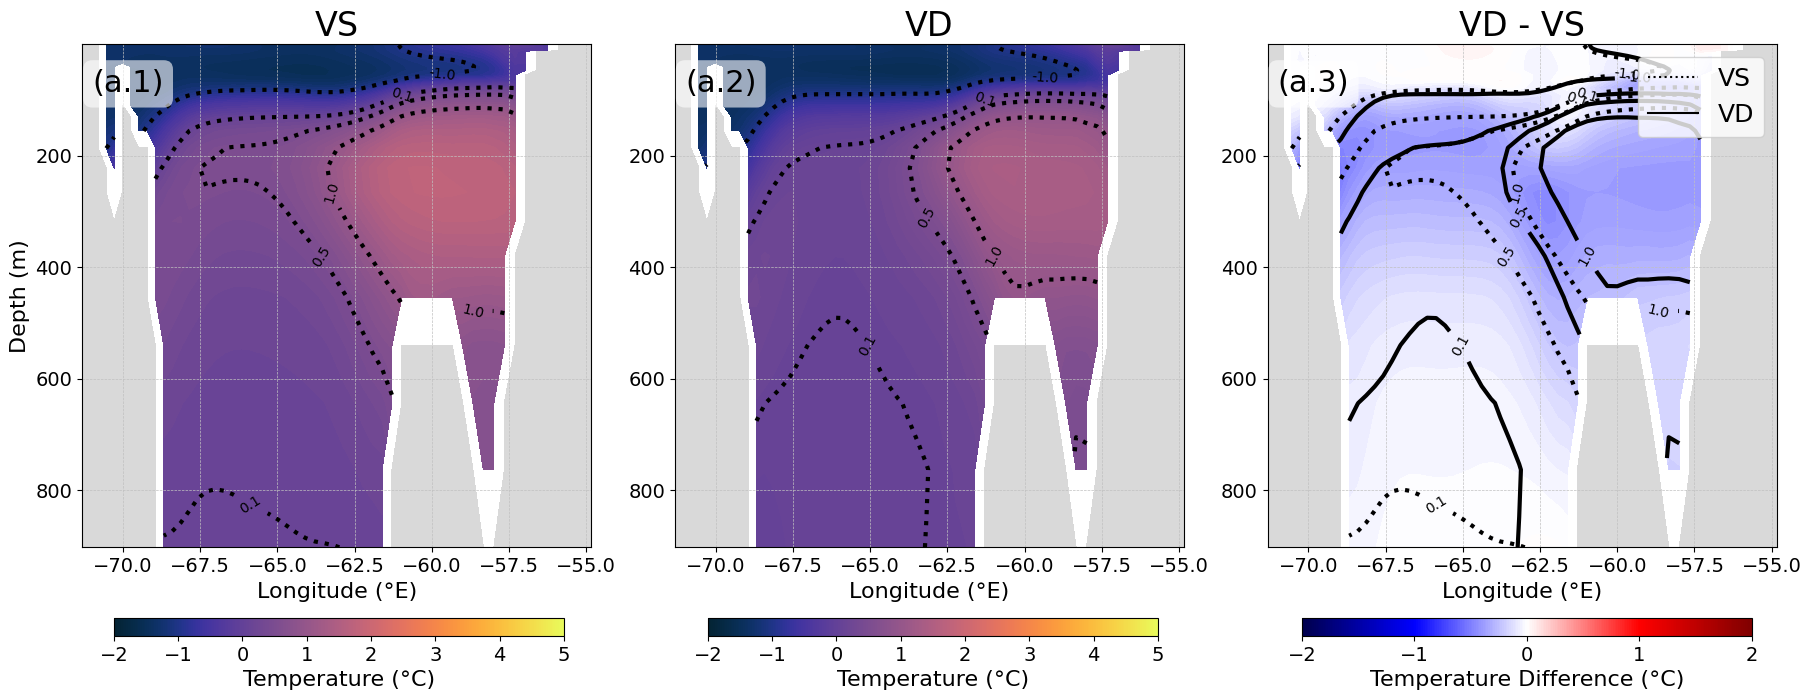

<Figure size 640x480 with 0 Axes>

In [28]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib as mpl
import numpy as np
import cmocean

# Color settings
vmin = -2 
vmax = 5
levels = 50
cmap = cmocean.cm.thermal
contour_cmap = truncate_colormap(plt.get_cmap('Greys'), minval=0.4, maxval=1, n=100)

#contour_levels = [-1, 1, 2] #for Davis Strait
contour_levels = [-1, 0.1, 0.5, 1] #for Baffin bay

# Set up figure and axes
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(18, 6), constrained_layout=True)

# Data and titles
data_list = [sec_temp_vs, sec_temp_vd, temp_sec_dif_vdvs]
titles = ['VS', 'VD', 'VD - VS']
cmaps = [cmap, cmap, 'seismic']
vmins = [vmin, vmin, -2]
vmaxs = [vmax, vmax, 2]
levels_list = [levels, levels, 20]

for i in range(3):
    cf = ax[i].contourf(xp, yp, data_list[i], levels=levels_list[i], 
                        vmin=vmins[i], vmax=vmaxs[i], cmap=cmaps[i])
    ax[i].contourf(xp, yp, mask, cmap='Greys')

    if i < 2:
        cont = ax[i].contour(xp, yp, data_list[i], levels=contour_levels,
                             colors = 'black', linestyles='dotted', linewidths=3)
        plt.clabel(cont, fmt='%1.1f', fontsize=10)
    else:
        cont_vs = ax[i].contour(xp, yp, sec_temp_vs, levels=contour_levels,
                                colors = 'black', linestyles='dotted', linewidths=3)
        plt.clabel(cont_vs, fmt='%1.1f', fontsize=10)
        cont_vd = ax[i].contour(xp, yp, sec_temp_vd, levels=contour_levels,
                                colors = 'black', linestyles='solid', linewidths=3)
        plt.clabel(cont_vd, fmt='%1.1f', fontsize=10)
        ax[i].legend([Line2D([0], [0], color='black', linestyle=':'),
                      Line2D([0], [0], color='black', linestyle='-')],
                     ['VS', 'VD'], fontsize=18, loc='upper right')

    ax[i].set_title(titles[i], fontsize=24)
    ax[i].set_ylim(max(sec_depth), min(depth))
    ax[i].grid(color='silver', linestyle='--', linewidth=0.5)
    ax[i].set_xlabel('Longitude (\u00B0E)', fontsize=16)
    ax[i].tick_params(axis='both', which='major', labelsize=14)  # Increase tick label font size to 14

    
    if i == 0:
        ax[i].set_ylabel('Depth (m)', fontsize=16)

# Colorbars (horizontal, one for each subplot)
cbar_height = 0.03
cbar_y = -0.05

for i in range(3):
    cax = fig.add_axes([0.06 + i*0.33, cbar_y, 0.25, cbar_height])  # [left, bottom, width, height]
    norm = mpl.colors.Normalize(vmin=vmins[i], vmax=vmaxs[i])
    cb = mpl.colorbar.ColorbarBase(cax, cmap=cmaps[i], norm=norm, orientation='horizontal')
    cb.ax.tick_params(labelsize=14) 
    if i < 2:
        cb.set_label('Temperature (\u00B0C)', fontsize=16)
    else:
        cb.set_label('Temperature Difference (\u00B0C)', fontsize=16)
        
        
labels = ['a.1', 'a.2', 'a.3']

for i, ax in enumerate(ax):
    # Add corner label in the upper-left corner of each subplot
    ax.text(0.02, 0.95, f'({labels[i]})', transform=ax.transAxes,
            fontsize=22, va='top', ha='left', 
           bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.3', alpha=0.6))


plt.show()
figure_title = 'TempBaffinBay' #or TempDavisStrait
os.chdir('/mnt/storage0/gabriela/ANALYSES/FIGS/figs_paper')
plt.savefig(figure_title + '.png', dpi=300, bbox_inches='tight')
plt.show()


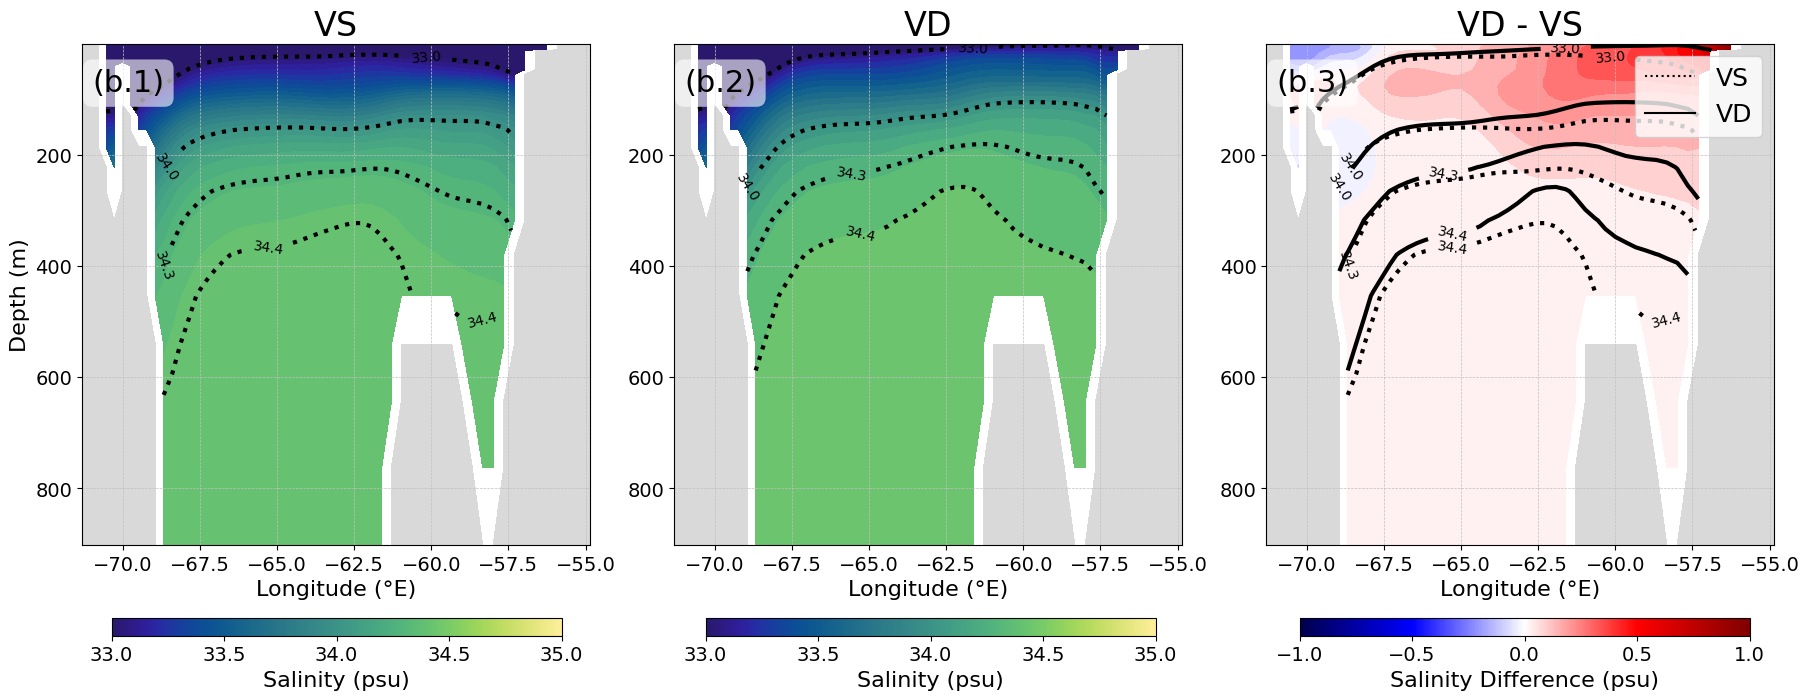

In [27]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib as mpl
import numpy as np
import cmocean

# Color settings
vmin = 33
vmax = 35
levels = 50
cmap = cmocean.cm.haline
contour_cmap = truncate_colormap(plt.get_cmap('Greys'), minval=0.4, maxval=1, n=100)

#contour_levels = [33, 34, 34.5] #for Davis Strait
contour_levels = [33, 34, 34.3, 34.4] #for Baffin bay

# Set up figure and axes
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(18, 6), constrained_layout=True)

# Data and titles
data_list = [sec_sal_vs, sec_sal_vd, sal_sec_dif_vdvs]
titles = ['VS', 'VD', 'VD - VS']
cmaps = [cmap, cmap, 'seismic']
vmins = [vmin, vmin, -1]
vmaxs = [vmax, vmax, 1]
levels_list = [levels, levels, 20]

for i in range(3):
    cf = ax[i].contourf(xp, yp, data_list[i], levels=levels_list[i], 
                        vmin=vmins[i], vmax=vmaxs[i], cmap=cmaps[i])
    ax[i].contourf(xp, yp, mask, cmap='Greys')

    if i < 2:
        cont = ax[i].contour(xp, yp, data_list[i], levels=contour_levels,
                             colors = 'black', linestyles='dotted', linewidths=3)
        plt.clabel(cont, fmt='%1.1f', fontsize=10)
    else:
        cont_vs = ax[i].contour(xp, yp, sec_sal_vs, levels=contour_levels,
                                colors = 'black', linestyles='dotted', linewidths=3)
        plt.clabel(cont_vs, fmt='%1.1f', fontsize=10)
        cont_vd = ax[i].contour(xp, yp, sec_sal_vd, levels=contour_levels,
                                colors = 'black', linestyles='solid', linewidths=3)
        plt.clabel(cont_vd, fmt='%1.1f', fontsize=10)
        ax[i].legend([Line2D([0], [0], color='black', linestyle=':'),
                      Line2D([0], [0], color='black', linestyle='-')],
                     ['VS', 'VD'], fontsize=18, loc='upper right')

    ax[i].set_title(titles[i], fontsize=24)
    ax[i].set_ylim(max(sec_depth), min(depth))
    ax[i].grid(color='silver', linestyle='--', linewidth=0.5)
    ax[i].set_xlabel('Longitude (\u00B0E)', fontsize=16)
    ax[i].tick_params(axis='both', which='major', labelsize=14)  # Increase tick label font size to 14

    
    if i == 0:
        ax[i].set_ylabel('Depth (m)', fontsize=16)

# Colorbars (horizontal, one for each subplot)
cbar_height = 0.03
cbar_y = -0.05

for i in range(3):
    cax = fig.add_axes([0.06 + i*0.33, cbar_y, 0.25, cbar_height])  # [left, bottom, width, height]
    norm = mpl.colors.Normalize(vmin=vmins[i], vmax=vmaxs[i])
    cb = mpl.colorbar.ColorbarBase(cax, cmap=cmaps[i], norm=norm, orientation='horizontal')
    cb.ax.tick_params(labelsize=14) 
    if i < 2:
        cb.set_label('Salinity', fontsize=16)
    else:
        cb.set_label('Salinity Difference', fontsize=16)
        
labels = ['b.1', 'b.2', 'b.3']

for i, ax in enumerate(ax):
    # Add corner label in the upper-left corner of each subplot
    ax.text(0.02, 0.95, f'({labels[i]})', transform=ax.transAxes,
            fontsize=22, va='top', ha='left',
            bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.3', alpha=0.6))        

        
figure_title = 'SalBaffinBay' # or SalDavisStrait
os.chdir('/mnt/storage0/gabriela/ANALYSES/FIGS/figs_paper')
plt.savefig(figure_title + '.png', dpi=300, bbox_inches='tight')
plt.show()

plt.show()


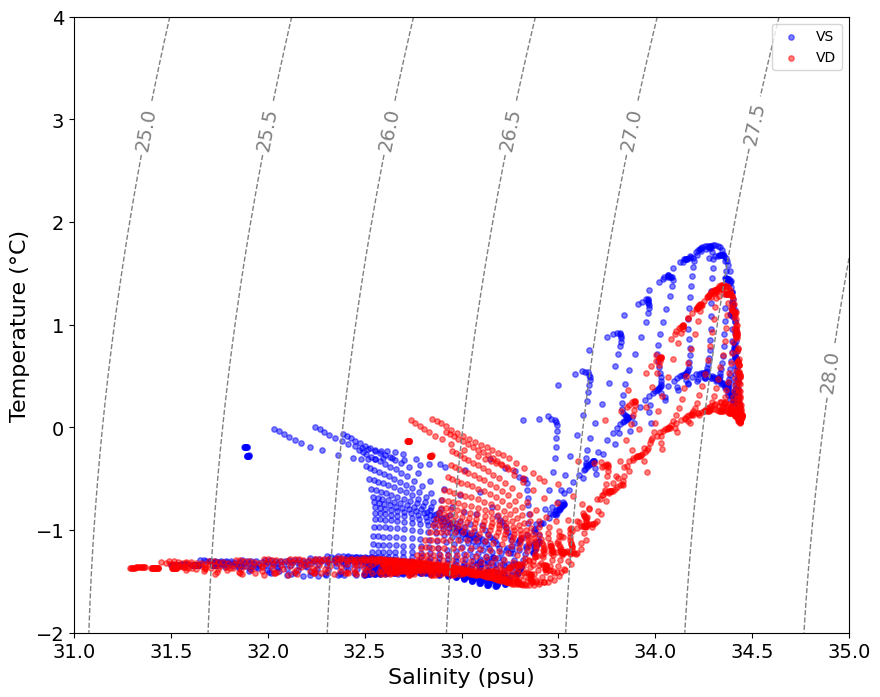

In [114]:
S_grid = np.linspace(31, 35, 100)
T_grid = np.linspace(-2, 4, 100)
Sg, Tg = np.meshgrid(S_grid, T_grid)

# 2. Convert to SA and CT (assuming surface pressure = 0 dbar, lon = 0, lat = 60°N)
SA = gsw.SA_from_SP(Sg, 0, 0, 60)
CT = gsw.CT_from_t(SA, Tg, 0)

# 3. Compute potential density anomaly (sigma0 = rho - 1000)
sigma0 = gsw.sigma0(SA, CT)

# Flatten the arrays
T_vs = sec_temp_vs.flatten()
S_vs = sec_sal_vs.flatten()

T_vd = sec_temp_vd.flatten()
S_vd = sec_sal_vd.flatten()

# Plot
plt.figure(figsize=(10, 8))
plt.scatter(S_vs, T_vs, color='blue', s=15, alpha=0.5, label='VS')
plt.scatter(S_vd, T_vd, color='red', s=15, alpha=0.5, label='VD')

cs = plt.contour(Sg, Tg, sigma0, colors='gray', linestyles='--', linewidths=1)
plt.clabel(cs, fmt='%1.1f', fontsize=14)

plt.xlabel('Salinity', fontsize = 16)
plt.ylabel('Temperature (°C)', fontsize = 16)
plt.xticks(fontsize=14)  # <-- increase x tick labels fontsize
plt.yticks(fontsize=14) 
plt.xlim(31, 35)  # example range for salinity
plt.legend()

figure_title = 'T-SDIAGRAMBaffinBay' # or T-SDIAGRAMDavisStrait
os.chdir('/mnt/storage0/gabriela/ANALYSES/FIGS/figs_paper')
plt.savefig(figure_title + '.png', dpi=300, bbox_inches='tight')
plt.show()
